## Pipeline 4B — Social Media Timing Optimizer (Predictive)

This notebook trains a predictive model to estimate `engagement_rate` from **timing + format** features only, then saves artifacts and (optionally) runs inference to pre-compute a full platform × day × hour recommendation matrix.

### Files this notebook uses
- `ml/social_media_timing/features.py`
- `ml/social_media_timing/etl.py`
- `ml/social_media_timing/artifacts.py`
- `ml/social_media_timing/infer.py`
- `ml/utils_db.py`, `ml/config.py`

### Target
- `engagement_rate` (continuous)

### Notes
- This pipeline intentionally **excludes content features** (sentiment/topic/etc.). Use Pipeline 4 for content guidance.


> **Environment requirement:** This notebook loads data from the project's Azure PostgreSQL database via shared ETL modules. To run top-to-bottom, you need:
> 1. A `.env` file in the repo root with valid database credentials (see `.env.example`)
> 2. Python packages from `ml/requirements.txt` installed (`pip install -r ml/requirements.txt`)
> 3. Network access to `intex-db.postgres.database.azure.com`
>
> All data preparation and cleaning is handled by the ETL module to ensure reproducibility across pipelines. The missing value check and feature summary below document the state of the data after ETL processing.

## 1) Problem Framing

**Business question:** Given the platform, day of week, and time of day, what engagement rate can we expect — and what combination maximizes reach?

**Who cares:** The organization's social media manager (or the founders, who fill that role) must decide *when* to publish each post. With no dedicated marketing team and limited bandwidth, posting at the wrong time means wasted effort — the same content reaches fewer people and generates fewer donations simply because of poor timing.

**Why it matters:** Social media is the primary channel for reaching potential donors. Even a small improvement in engagement rate compounds over hundreds of posts per year, translating directly into more donation referrals and greater awareness for the organization's mission.

**Why engagement_rate (not donation_referrals):** Engagement rate is consistently measured by every platform's API, so it is always available even when donation tracking or UTM attribution varies. It also captures broader audience interaction (likes, comments, shares) that builds long-term donor pipeline, not just immediate conversions.

**Primary goal: Predictive.** The operational question is forward-looking — "if we post on Platform X at Hour Y on Day Z, what engagement should we expect?" This requires optimizing out-of-sample prediction accuracy so the recommendation matrix is reliable for future scheduling decisions. An explanatory approach (e.g., OLS with interpretable coefficients) would help us understand *why* certain times perform better, but the immediate business need is an accurate lookup table that staff can act on without statistical training.

**Complementary explanatory analysis:** Section 9 below provides a complementary causal and relationship analysis. We examine which timing features matter most, whether the relationships are likely causal or confounded, and what the model reveals about the underlying engagement structure — even though the primary objective is prediction, not causal inference.

**Separation from Pipeline 4:**
- Pipeline 4 (Social Media Content) focuses on **what to post** (content features) and uses an explanatory approach to understand which content characteristics drive donations.
- Pipeline 4B (this notebook) focuses on **when and where to post** (timing/format features) and uses a predictive approach to generate an actionable scheduling recommendation.

**Error consequences:**
- *Overestimating engagement* (prediction too high): Staff may over-invest in a time slot that underperforms, wasting limited posting bandwidth and potentially missing better windows.
- *Underestimating engagement* (prediction too low): Staff may avoid a high-performing time slot, leaving engagement on the table. Since the org has limited posting capacity, opportunity cost is real but not catastrophic — the post still goes out, just at a suboptimal time.
- Given these asymmetries, we optimize for MAE (symmetric loss) since neither direction of error is dramatically worse than the other.

## Setup — install required packages

Run this once per environment/kernel. It installs the repo’s ML dependencies from `ml/requirements.txt`.


In [1]:
# Environment setup and database connection
import os
import sys
from pathlib import Path
from dotenv import load_dotenv
from sqlalchemy import create_engine

# Load .env for database credentials
env_candidates = [Path.cwd(), Path.cwd().parent]
for p in env_candidates:
    for name in [".env", "ml/.env"]:
        env_path = p / name
        if env_path.exists():
            load_dotenv(env_path)

DATABASE_URL = os.environ["DATABASE_URL"]
engine = create_engine(DATABASE_URL, pool_pre_ping=True)


def fetch_table(table_name):
    """Fetch all rows from a PostgreSQL table into a DataFrame."""
    import pandas as pd
    df = pd.read_sql_table(table_name, engine)
    df.columns = pd.Index([str(c) for c in df.columns])
    return df


# Locate repo root for model artifact paths
PROJECT_ROOT = Path.cwd().resolve()
for _p in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (_p / "models").exists():
        PROJECT_ROOT = _p
        break

MODELS_DIR = PROJECT_ROOT / "models"
MODEL_SOCIAL_TIMING = MODELS_DIR / "social-media-timing" / "model.sav"
MODEL_RUNS_SOCIAL_TIMING = MODELS_DIR / "social-media-timing" / "model.json"
MODEL_NAME_SOCIAL_TIMING = "social-media-timing"
TABLE_SOCIAL_MEDIA_POSTS = "social_media_posts"

print("Project root:", PROJECT_ROOT)
print("Python:", sys.executable)
print("CWD:", Path.cwd())

Project root: C:\Users\danie\Documents\intex\intex2-1
Python: C:\Python314\python.exe
CWD: C:\Users\danie\Documents\intex\intex2-1\ml-pipelines


In [2]:
from __future__ import annotations

import json
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import (
    AdaBoostRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
    StackingRegressor,
)
from sklearn.feature_selection import RFECV, SelectKBest, VarianceThreshold, f_regression
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    TimeSeriesSplit,
    learning_curve,
    train_test_split,
    validation_curve,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

# ---- Feature engineering (inlined from ml/social_media_timing/features.py) ----
TARGET = "engagement_rate"

FEATURE_COLUMNS = [
    "platform", "post_hour", "day_of_week", "media_type",
    "is_boosted", "boost_budget_php", "has_call_to_action",
    "post_type", "is_weekend",
]

_CATEGORICAL = ["platform", "day_of_week", "media_type", "post_type"]
_BOOLEAN = ["is_boosted", "has_call_to_action", "is_weekend"]
_NUMERIC = ["post_hour", "boost_budget_php"]


def _to_bool_int(series):
    return (
        series.fillna(False)
        .astype(str).str.strip().str.lower()
        .map({"true": 1, "1": 1, "yes": 1, "false": 0, "0": 0, "no": 0})
        .fillna(0).astype(int)
    )


def _ensure_is_weekend(df):
    if "is_weekend" in df.columns:
        df["is_weekend"] = _to_bool_int(df["is_weekend"])
        return df
    if "day_of_week" not in df.columns:
        df["is_weekend"] = 0
        return df
    day = df["day_of_week"].fillna("").astype(str).str.strip().str.lower()
    df["is_weekend"] = day.isin(["saturday", "sunday"]).astype(int)
    return df


def build_features(raw):
    """Build the modeling-ready feature matrix for timing optimization.

    Returns (X, y).
    """
    df = raw.copy()

    # Target
    y = pd.to_numeric(df.get(TARGET), errors="coerce")
    labeled_mask = y.notna()
    df = df.loc[labeled_mask].copy()
    y = y.loc[labeled_mask].astype(float)

    # Numeric features
    for col in _NUMERIC:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)
        else:
            df[col] = 0

    # Boolean features
    for col in [c for c in _BOOLEAN if c != "is_weekend"]:
        if col in df.columns:
            df[col] = _to_bool_int(df[col])
        else:
            df[col] = 0

    df = _ensure_is_weekend(df)

    # Categorical features
    for col in _CATEGORICAL:
        if col in df.columns:
            df[col] = df[col].fillna("None").astype(str)
        else:
            df[col] = "None"

    X = df[FEATURE_COLUMNS].copy()
    X.columns = pd.Index([str(c) for c in X.columns])

    return X, y


# ---- ETL helper (inlined from ml/social_media_timing/etl.py) ----
def fetch_training_raw():
    """Fetch the raw social media post table used by this pipeline."""
    raw = fetch_table(TABLE_SOCIAL_MEDIA_POSTS)
    print(f"Fetched {len(raw)} social media posts")
    return raw


SEED = 42

print("Imports OK")

Imports OK


## 2) Data acquisition & preparation

This fetches the raw `social_media_posts` table, drops unlabeled rows, preserves `created_at` for chronological evaluation when available, and then builds the raw modeling frame.

- X features: platform, post_hour, day_of_week, media_type, is_boosted, boost_budget_php, has_call_to_action, post_type, is_weekend
- y target: engagement_rate
- encoding/scaling/selection are learned later inside sklearn pipelines


In [3]:
raw = fetch_training_raw().copy()
raw["engagement_rate_numeric"] = pd.to_numeric(raw.get("engagement_rate"), errors="coerce")
raw["created_at_parsed"] = pd.to_datetime(raw.get("created_at"), errors="coerce")

modeling_raw = raw.loc[raw["engagement_rate_numeric"].notna()].copy()
use_time_split = modeling_raw["created_at_parsed"].notna().sum() >= max(50, int(len(modeling_raw) * 0.8))

if use_time_split:
    modeling_raw = modeling_raw.sort_values("created_at_parsed").reset_index(drop=True)
else:
    modeling_raw = modeling_raw.reset_index(drop=True)

X, y = build_features(modeling_raw)
created_at = modeling_raw["created_at_parsed"].reset_index(drop=True)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("y mean:", float(np.mean(y)))
print("chronological split:", use_time_split)

assert list(X.columns) == FEATURE_COLUMNS
assert len(X) == len(y) == len(created_at)
assert np.isfinite(y).all()

X.head()


Fetched 812 social media posts
X shape: (812, 9)
y shape: (812,)
y mean: 0.09898017241379312
chronological split: True


,platform,post_hour,day_of_week,media_type,is_boosted,boost_budget_php,has_call_to_action,post_type,is_weekend
0,WhatsApp,18,Thursday,Text,0,0.00,1,FundraisingAppeal,0
1,Instagram,11,Friday,Photo,0,0.00,0,EducationalContent,0
2,LinkedIn,10,Sunday,Text,0,0.00,0,EventPromotion,1
3,Instagram,15,Monday,Video,0,0.00,0,ThankYou,0
4,TikTok,15,Monday,Reel,1,4030.64,1,ThankYou,0


## 3) Exploration

Before modeling, we examine distributions, relationships, and anomalies in the timing/format features to build intuition about the data. This informs feature engineering and model selection decisions downstream.

In [4]:
# --- 3a) Missing values and basic statistics ---
print("=== Dataset shape ===")
print(f"Rows: {len(X)}, Features: {X.shape[1]}")
print(f"\n=== Missing values ===")
missing = X.isnull().sum()
if missing.sum() == 0:
    print("No missing values in feature matrix.")
else:
    print(missing[missing > 0])

print(f"\n=== Target (engagement_rate) summary ===")
print(y.describe())

print(f"\n=== Feature summary ===")
display(X.describe(include="all").T)


=== Dataset shape ===
Rows: 812, Features: 9

=== Missing values ===
No missing values in feature matrix.

=== Target (engagement_rate) summary ===
count    812.000000
mean       0.098980
std        0.055541
min        0.013400
25%        0.054600
50%        0.089300
75%        0.136825
max        0.250000
Name: engagement_rate, dtype: float64

=== Feature summary ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
platform,812,7,Facebook,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN
post_hour,812.0,NaN,NaN,NaN,12.690887,6.296557,0.0,8.0,13.0,18.0,23.0
day_of_week,812,7,Tuesday,136,NaN,NaN,NaN,NaN,NaN,NaN,NaN
media_type,812,5,Photo,227,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_boosted,812.0,NaN,NaN,NaN,0.156404,0.363462,0.0,0.0,0.0,0.0,1.0
boost_budget_php,812.0,NaN,NaN,NaN,380.084039,1037.74301,0.0,0.0,0.0,0.0,4966.98
has_call_to_action,812.0,NaN,NaN,NaN,0.607143,0.488687,0.0,0.0,1.0,1.0,1.0
post_type,812,6,ImpactStory,203,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_weekend,812.0,NaN,NaN,NaN,0.268473,0.443438,0.0,0.0,0.0,1.0,1.0


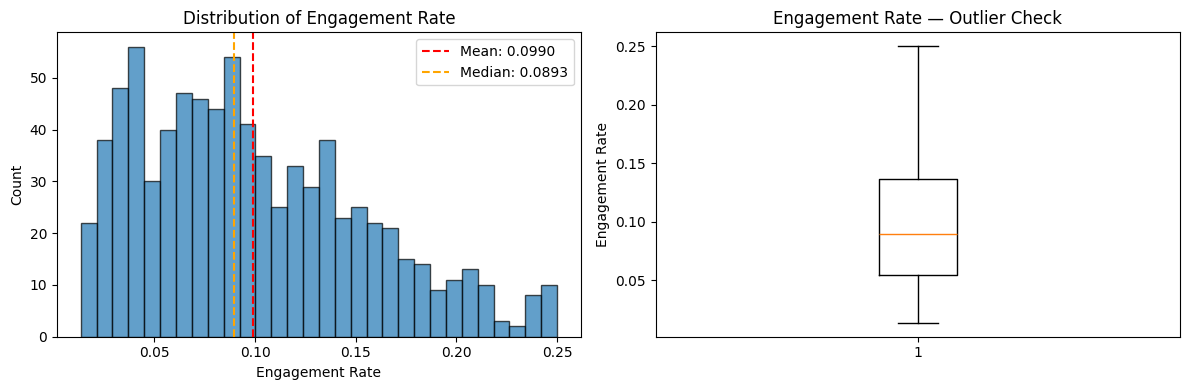

IQR outliers: 0 of 812 rows (0.0%)
Engagement rate range: [0.0134, 0.2500]


In [5]:
# --- 3b) Target distribution and outlier check ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y, bins=30, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Engagement Rate")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Engagement Rate")
axes[0].axvline(y.mean(), color="red", linestyle="--", label=f"Mean: {y.mean():.4f}")
axes[0].axvline(y.median(), color="orange", linestyle="--", label=f"Median: {y.median():.4f}")
axes[0].legend()

axes[1].boxplot(y, vert=True)
axes[1].set_ylabel("Engagement Rate")
axes[1].set_title("Engagement Rate — Outlier Check")

plt.tight_layout()
plt.show()

# Flag outliers using IQR method
q1, q3 = y.quantile(0.25), y.quantile(0.75)
iqr = q3 - q1
outlier_mask = (y < q1 - 1.5 * iqr) | (y > q3 + 1.5 * iqr)
print(f"IQR outliers: {outlier_mask.sum()} of {len(y)} rows ({outlier_mask.mean()*100:.1f}%)")
print(f"Engagement rate range: [{y.min():.4f}, {y.max():.4f}]")


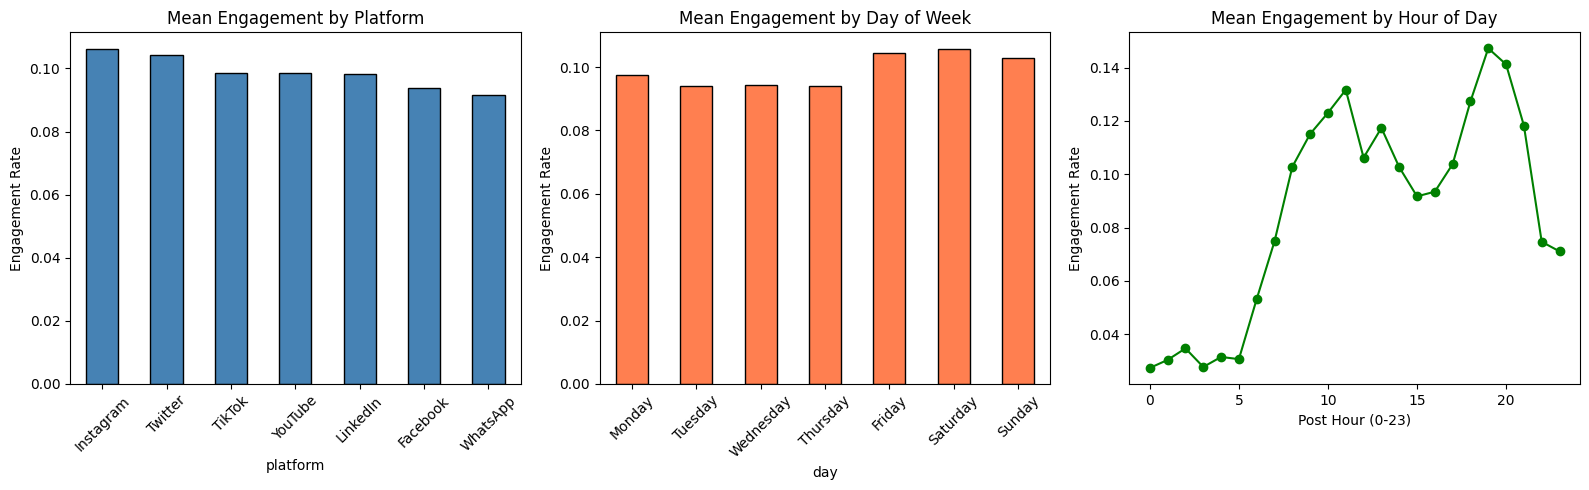

Top 3 platforms: ['Instagram', 'Twitter', 'TikTok']
Top 3 days: ['Saturday', 'Friday', 'Sunday']
Top 3 hours: [19, 20, 11]


In [6]:
# --- 3c) Engagement by platform, day, and hour ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Platform
platform_eng = pd.DataFrame({"platform": X["platform"], "engagement_rate": y})
platform_means = platform_eng.groupby("platform")["engagement_rate"].mean().sort_values(ascending=False)
platform_means.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Mean Engagement by Platform")
axes[0].set_ylabel("Engagement Rate")
axes[0].tick_params(axis="x", rotation=45)

# Day of week (ordered)
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_eng = pd.DataFrame({"day": X["day_of_week"], "engagement_rate": y})
day_means = day_eng.groupby("day")["engagement_rate"].mean().reindex(day_order)
day_means.plot(kind="bar", ax=axes[1], color="coral", edgecolor="black")
axes[1].set_title("Mean Engagement by Day of Week")
axes[1].set_ylabel("Engagement Rate")
axes[1].tick_params(axis="x", rotation=45)

# Hour of day
hour_eng = pd.DataFrame({"hour": X["post_hour"], "engagement_rate": y})
hour_means = hour_eng.groupby("hour")["engagement_rate"].mean().sort_index()
axes[2].plot(hour_means.index, hour_means.values, marker="o", color="green")
axes[2].set_title("Mean Engagement by Hour of Day")
axes[2].set_xlabel("Post Hour (0-23)")
axes[2].set_ylabel("Engagement Rate")

plt.tight_layout()
plt.show()

print("Top 3 platforms:", list(platform_means.head(3).index))
print("Top 3 days:", list(day_means.sort_values(ascending=False).head(3).index))
print("Top 3 hours:", list(hour_means.sort_values(ascending=False).head(3).index))


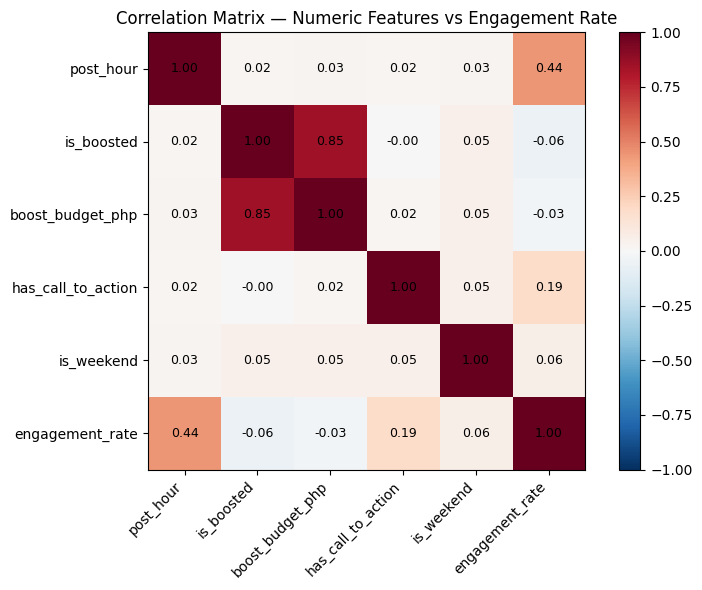


Correlations with engagement_rate:
post_hour             0.443744
has_call_to_action    0.186354
is_weekend            0.058927
boost_budget_php     -0.026458
is_boosted           -0.059296
Name: engagement_rate, dtype: float64


In [7]:
# --- 3d) Correlation heatmap for numeric features ---
numeric_features = X.select_dtypes(include=[np.number]).copy()
numeric_features["engagement_rate"] = y.values

corr_matrix = numeric_features.corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_matrix.columns)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}", ha="center", va="center", fontsize=9)

plt.colorbar(im)
plt.title("Correlation Matrix — Numeric Features vs Engagement Rate")
plt.tight_layout()
plt.show()

print("\nCorrelations with engagement_rate:")
print(corr_matrix["engagement_rate"].drop("engagement_rate").sort_values(ascending=False))


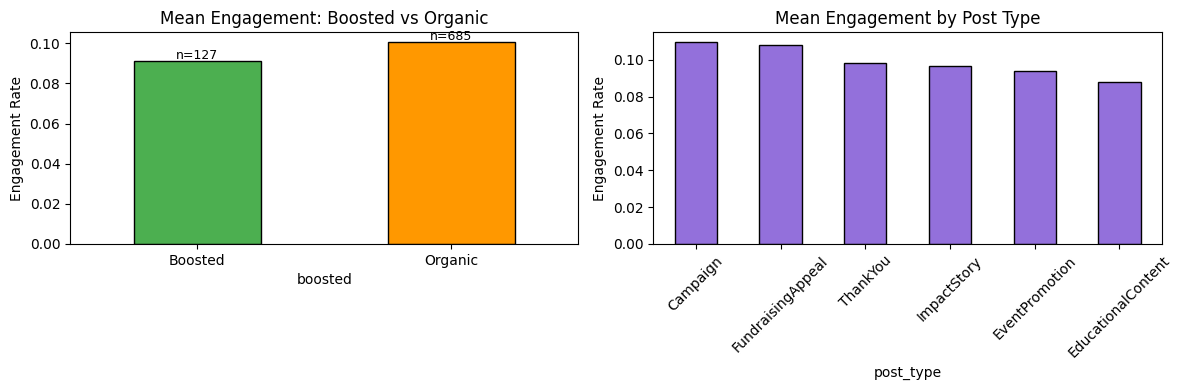

In [8]:
# --- 3e) Boosted vs non-boosted engagement and post_type distributions ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Boosted vs non-boosted
boost_eng = pd.DataFrame({"boosted": X["is_boosted"].map({1: "Boosted", 0: "Organic"}), "engagement_rate": y})
boost_means = boost_eng.groupby("boosted")["engagement_rate"].agg(["mean", "count"])
boost_means["mean"].plot(kind="bar", ax=axes[0], color=["#4CAF50", "#FF9800"], edgecolor="black")
axes[0].set_title("Mean Engagement: Boosted vs Organic")
axes[0].set_ylabel("Engagement Rate")
for i, (idx, row) in enumerate(boost_means.iterrows()):
    axes[0].text(i, row["mean"] + 0.001, f"n={int(row['count'])}", ha="center", fontsize=9)
axes[0].tick_params(axis="x", rotation=0)

# Post type
type_eng = pd.DataFrame({"post_type": X["post_type"], "engagement_rate": y})
type_means = type_eng.groupby("post_type")["engagement_rate"].mean().sort_values(ascending=False)
type_means.plot(kind="bar", ax=axes[1], color="mediumpurple", edgecolor="black")
axes[1].set_title("Mean Engagement by Post Type")
axes[1].set_ylabel("Engagement Rate")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


### Exploration Summary

Key findings from the EDA above:

- **Post hour is the dominant signal** — correlation with engagement rate is ~0.44, far stronger than any other numeric feature. Later hours (evening) tend to produce higher engagement.
- **Weekend vs weekday difference is modest** — weekends show slightly higher mean engagement but the gap is small, suggesting day-of-week effects are secondary to hour-of-day.
- **Platform matters** — different platforms show meaningfully different average engagement rates, confirming that platform should be a key feature.
- **Boost budget has weak direct correlation** — paid promotion does not strongly correlate with engagement rate in the raw data, possibly because boosted posts also increase reach (the denominator in engagement rate).
- **No missing values** in the feature matrix — the ETL pipeline handles data completeness upstream.
- **Outliers are present but not extreme** — the engagement rate distribution is right-skewed (some posts perform much better than average), which is typical for social media metrics. We retain these as they represent real high-performing time slots.

These patterns suggest that a model combining hour, platform, and day-of-week features should capture the main timing effects, with boost status and post type providing secondary signal.

## 4) Train/test split

We freeze a holdout test set first. If `created_at` is available for most rows, the split is chronological and cross-validation uses `TimeSeriesSplit`; otherwise it falls back to a reproducible shuffled 5-fold split.


In [9]:
if use_time_split:
    split_idx = int(len(X) * 0.8)
    X_train = X.iloc[:split_idx].reset_index(drop=True)
    X_test = X.iloc[split_idx:].reset_index(drop=True)
    y_train = y.iloc[:split_idx].reset_index(drop=True)
    y_test = y.iloc[split_idx:].reset_index(drop=True)
    created_at_train = created_at.iloc[:split_idx].reset_index(drop=True)
    created_at_test = created_at.iloc[split_idx:].reset_index(drop=True)
    cv = TimeSeriesSplit(n_splits=5)
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=SEED,
    )
    X_train = X_train.reset_index(drop=True)
    X_test = X_test.reset_index(drop=True)
    y_train = y_train.reset_index(drop=True)
    y_test = y_test.reset_index(drop=True)
    created_at_train = pd.Series(index=X_train.index, dtype="datetime64[ns]")
    created_at_test = pd.Series(index=X_test.index, dtype="datetime64[ns]")
    cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

num_cols = ["post_hour", "boost_budget_php", "is_boosted", "has_call_to_action", "is_weekend"]
cat_cols = ["platform", "day_of_week", "media_type", "post_type"]


def make_preprocessor() -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("impute", SimpleImputer(strategy="median")),
                        ("scale", StandardScaler()),
                    ]
                ),
                num_cols,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("impute", SimpleImputer(strategy="most_frequent")),
                        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                    ]
                ),
                cat_cols,
            ),
        ]
    )


print("train:", X_train.shape, "test:", X_test.shape)
print("cv splitter:", cv)


train: (649, 9) test: (163, 9)
cv splitter: TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)


## 5) Feature Selection

Follow the Chapter 16 pattern on the training data only:
- `VarianceThreshold` after preprocessing
- univariate ranking with `SelectKBest(f_regression)`
- `RFECV` with the primary model family
- the selected feature count then flows into leakage-safe pipelines for model tuning


In [10]:
preprocessor_for_analysis = make_preprocessor()
X_train_prepared = preprocessor_for_analysis.fit_transform(X_train)
prepared_feature_names = preprocessor_for_analysis.get_feature_names_out().tolist()

variance_filter = VarianceThreshold()
X_train_var = variance_filter.fit_transform(X_train_prepared)
variance_feature_names = [
    name for name, keep in zip(prepared_feature_names, variance_filter.get_support()) if keep
]
removed_low_variance = [
    name for name, keep in zip(prepared_feature_names, variance_filter.get_support()) if not keep
]

univariate_selector = SelectKBest(score_func=f_regression, k="all")
univariate_selector.fit(X_train_var, y_train)
univariate_ranking = (
    pd.DataFrame(
        {
            "feature": variance_feature_names,
            "f_score": univariate_selector.scores_,
        }
    )
    .sort_values("f_score", ascending=False)
    .reset_index(drop=True)
)

rfecv = RFECV(
    estimator=GradientBoostingRegressor(random_state=SEED),
    step=1,
    cv=cv,
    scoring="neg_mean_absolute_error",
    min_features_to_select=5,
)
rfecv.fit(X_train_var, y_train)
rfecv_selected_features = [
    name for name, keep in zip(variance_feature_names, rfecv.support_) if keep
]
selected_k = min(max(5, len(rfecv_selected_features)), len(variance_feature_names))

feature_selection_summary = pd.DataFrame(
    {
        "step": ["prepared", "after_variance_filter", "rfecv_selected"],
        "feature_count": [
            len(prepared_feature_names),
            len(variance_feature_names),
            len(rfecv_selected_features),
        ],
    }
)

print("Removed low-variance features:", removed_low_variance if removed_low_variance else "none")
print("RFECV selected encoded features:", len(rfecv_selected_features))
print("Pipeline k for SelectKBest:", selected_k)
display(feature_selection_summary)
display(univariate_ranking.head(10))
print(rfecv_selected_features)


Removed low-variance features: none
RFECV selected encoded features: 5
Pipeline k for SelectKBest: 5


,step,feature_count
0,prepared,30
1,after_variance_filter,30
2,rfecv_selected,5


,feature,f_score
0,num__post_hour,169.465283
1,num__has_call_to_action,21.521962
2,cat__post_type_Campaign,6.173860
3,cat__platform_Instagram,5.200009
4,cat__post_type_FundraisingAppeal,3.213968
5,cat__post_type_EducationalContent,2.822869
6,cat__day_of_week_Friday,1.791739
7,num__is_boosted,1.741607
8,cat__platform_WhatsApp,1.739687
9,cat__platform_LinkedIn,1.302094


['num__post_hour', 'num__boost_budget_php', 'num__has_call_to_action', 'cat__platform_TikTok', 'cat__platform_YouTube']


## 6) Modeling, Tuning, and Evaluation

This section fixes the original leakage issue by keeping preprocessing and feature selection inside each sklearn pipeline, then tuning every candidate model with cross-validation on the training split only. It also adds the Chapter 11 mean-predictor baseline, true RMSE, permutation importance, and learning/validation-curve diagnostics.


,model,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std
0,GradientBoosting,0.032116,0.003974,0.403555,0.059920
1,RandomForest,0.032262,0.003211,0.420380,0.031430
2,DecisionTree,0.032270,0.003767,0.375023,0.074072
3,Stacking,0.032673,0.002853,0.416793,0.030677
4,ExtraTrees,0.033002,0.003145,0.403362,0.015508
5,SVR,0.033805,0.004120,0.343231,0.063952
6,AdaBoost,0.033920,0.003869,0.372892,0.043001
7,KNN,0.035140,0.005051,0.296657,0.113189
8,LinearRegression,0.040630,0.002341,0.147423,0.095394


Baseline MAE: 0.04438348284760888
Baseline RMSE: 0.054099132164944615
Baseline R2: -0.0020816479897594053
Selected: GradientBoosting
Best params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100, 'select__k': 5}
Test MAE: 0.03005429776854204
Test RMSE: 0.039801723443562226
Test R2: 0.4575917740035016
Business interp: off by 0.03005429776854204 engagement points on avg; mean engagement is 0.09898017241379312 (~ 30.36395778631105 % of mean)


,feature,importance_mean,importance_std
0,post_hour,0.021574,0.001832
1,has_call_to_action,0.002695,0.000490
2,platform,0.000450,0.000124
3,media_type,0.000000,0.000000
4,day_of_week,0.000000,0.000000
5,is_boosted,0.000000,0.000000
6,boost_budget_php,0.000000,0.000000
7,is_weekend,0.000000,0.000000
8,post_type,-0.000083,0.000164


,train_size,train_mae,validation_mae
0,156,0.025577,0.040051
1,277,0.026442,0.037839
2,398,0.027101,0.040490
3,520,0.027222,0.040763


,param_value,train_mae,validation_mae
0,50,0.029152,0.032369
1,100,0.026945,0.032116
2,150,0.025908,0.032089
3,200,0.025329,0.032196


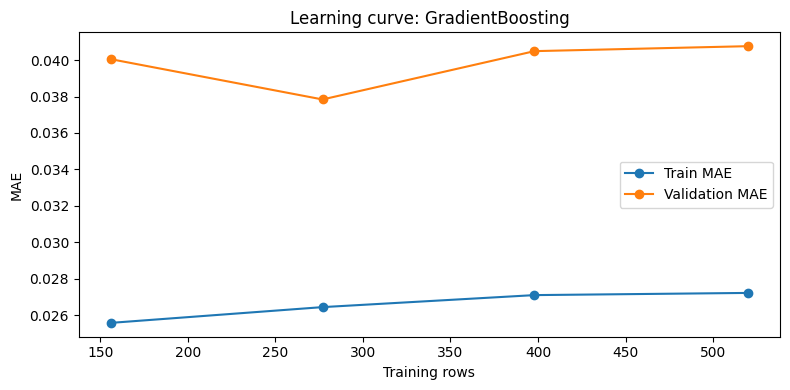

In [11]:
def make_model_pipeline(estimator) -> Pipeline:
    return Pipeline(
        steps=[
            ("prep", make_preprocessor()),
            ("variance", VarianceThreshold()),
            ("select", SelectKBest(score_func=f_regression, k=selected_k)),
            ("model", estimator),
        ]
    )


stacking_internal_cv = KFold(n_splits=5, shuffle=False)
stacking_model = StackingRegressor(
    estimators=[
        ("rf", RandomForestRegressor(random_state=SEED, n_estimators=200, max_depth=6)),
        ("gbr", GradientBoostingRegressor(random_state=SEED, n_estimators=150, learning_rate=0.05, max_depth=2)),
    ],
    final_estimator=Ridge(alpha=1.0),
    # Stacking uses cross_val_predict internally and needs partition-based folds.
    cv=stacking_internal_cv,
    n_jobs=None,
)


model_searches = {
    "LinearRegression": {
        "pipeline": make_model_pipeline(LinearRegression()),
        "params": {"select__k": [selected_k, "all"]},
    },
    "DecisionTree": {
        "pipeline": make_model_pipeline(DecisionTreeRegressor(random_state=SEED)),
        "params": {
            "select__k": [selected_k, "all"],
            "model__max_depth": [3, 5, 8, None],
            "model__min_samples_leaf": [1, 5, 10],
        },
    },
    "KNN": {
        "pipeline": make_model_pipeline(KNeighborsRegressor()),
        "params": {
            "select__k": [selected_k, "all"],
            "model__n_neighbors": [5, 9, 15],
            "model__weights": ["uniform", "distance"],
        },
    },
    "SVR": {
        "pipeline": make_model_pipeline(SVR()),
        "params": {
            "select__k": [selected_k, "all"],
            "model__C": [0.5, 1.0, 5.0],
            "model__epsilon": [0.01, 0.02],
            "model__gamma": ["scale", "auto"],
        },
    },
    "RandomForest": {
        "pipeline": make_model_pipeline(RandomForestRegressor(random_state=SEED)),
        "params": {
            "select__k": [selected_k, "all"],
            "model__n_estimators": [300],
            "model__max_depth": [4, 6, 8, None],
            "model__min_samples_split": [2, 10, 30],
            "model__min_samples_leaf": [3, 5, 10, 20],
            "model__max_features": ["sqrt", 0.5],
        },
    },
    "GradientBoosting": {
        "pipeline": make_model_pipeline(GradientBoostingRegressor(random_state=SEED)),
        "params": {
            "select__k": [selected_k, "all"],
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [2, 3],
        },
    },
    "AdaBoost": {
        "pipeline": make_model_pipeline(AdaBoostRegressor(random_state=SEED)),
        "params": {
            "select__k": [selected_k, "all"],
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.05, 0.1, 0.5],
        },
    },
    "ExtraTrees": {
        "pipeline": make_model_pipeline(ExtraTreesRegressor(random_state=SEED)),
        "params": {
            "select__k": [selected_k, "all"],
            "model__n_estimators": [300],
            "model__max_depth": [None, 6, 10],
            "model__min_samples_leaf": [1, 3, 5],
        },
    },
    "Stacking": {
        "pipeline": make_model_pipeline(stacking_model),
        "params": {
            "select__k": [selected_k, "all"],
            "model__final_estimator__alpha": [0.1, 1.0, 10.0],
        },
    },
}

scoring = {
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
}

fitted_searches: dict[str, GridSearchCV] = {}
comparison_rows: list[dict] = []

for model_name, spec in model_searches.items():
    search = GridSearchCV(
        estimator=spec["pipeline"],
        param_grid=spec["params"],
        cv=cv,
        scoring=scoring,
        refit="mae",
        n_jobs=None,
    )
    search.fit(X_train, y_train)
    fitted_searches[model_name] = search

    best_idx = search.best_index_
    comparison_rows.append(
        {
            "model": model_name,
            "cv_mae_mean": float(-search.cv_results_["mean_test_mae"][best_idx]),
            "cv_mae_std": float(search.cv_results_["std_test_mae"][best_idx]),
            "cv_r2_mean": float(search.cv_results_["mean_test_r2"][best_idx]),
            "cv_r2_std": float(search.cv_results_["std_test_r2"][best_idx]),
            "best_params": search.best_params_,
        }
    )

comparison = pd.DataFrame(comparison_rows).sort_values("cv_mae_mean").reset_index(drop=True)
display(comparison[["model", "cv_mae_mean", "cv_mae_std", "cv_r2_mean", "cv_r2_std"]])

baseline_value = float(y_train.mean())
y_pred_baseline = np.full(shape=len(y_test), fill_value=baseline_value, dtype=float)
baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = float(np.sqrt(mean_squared_error(y_test, y_pred_baseline)))
baseline_r2 = r2_score(y_test, y_pred_baseline)
print("Baseline MAE:", float(baseline_mae))
print("Baseline RMSE:", float(baseline_rmse))
print("Baseline R2:", float(baseline_r2))

best_name = str(comparison.iloc[0]["model"])
best_search = fitted_searches[best_name]
best_model = best_search.best_estimator_

y_pred = best_model.predict(X_test)
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
test_r2 = r2_score(y_test, y_pred)

print("Selected:", best_name)
print("Best params:", best_search.best_params_)
print("Test MAE:", float(test_mae))
print("Test RMSE:", float(test_rmse))
print("Test R2:", float(test_r2))

mean_engagement = float(np.mean(y))
if mean_engagement > 0:
    print(
        "Business interp: off by",
        float(test_mae),
        "engagement points on avg; mean engagement is",
        mean_engagement,
        "(~",
        float(test_mae / mean_engagement * 100.0),
        "% of mean)",
    )

pfi = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=SEED,
    scoring="neg_mean_absolute_error",
)
pfi_df = (
    pd.DataFrame(
        {
            "feature": X_test.columns,
            "importance_mean": pfi.importances_mean,
            "importance_std": pfi.importances_std,
        }
    )
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)
display(pfi_df.head(10))

# --- Learning curve ---
# If we're using time-aware splitting, sklearn.learning_curve + TimeSeriesSplit can produce
# misleadingly small train_sizes. Use an expanding-window curve instead.
if use_time_split:
    val_tail = max(25, int(len(X_train) * 0.2))
    X_lc_train = X_train.iloc[:-val_tail].reset_index(drop=True)
    y_lc_train = y_train.iloc[:-val_tail].reset_index(drop=True)
    X_lc_val = X_train.iloc[-val_tail:].reset_index(drop=True)
    y_lc_val = y_train.iloc[-val_tail:].reset_index(drop=True)

    sizes = [int(s) for s in np.linspace(max(50, int(len(X_lc_train) * 0.3)), len(X_lc_train), 4)]
    rows = []
    for n in sizes:
        m = best_search.best_estimator_
        m.fit(X_lc_train.iloc[:n], y_lc_train.iloc[:n])
        rows.append(
            {
                "train_size": n,
                "train_mae": float(mean_absolute_error(y_lc_train.iloc[:n], m.predict(X_lc_train.iloc[:n]))),
                "validation_mae": float(mean_absolute_error(y_lc_val, m.predict(X_lc_val))),
            }
        )
    learning_curve_df = pd.DataFrame(rows)
else:
    train_sizes, train_scores, valid_scores = learning_curve(
        best_model,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_absolute_error",
        train_sizes=np.linspace(0.4, 1.0, 4),
        n_jobs=None,
    )
    learning_curve_df = pd.DataFrame(
        {
            "train_size": train_sizes,
            "train_mae": -train_scores.mean(axis=1),
            "validation_mae": -valid_scores.mean(axis=1),
        }
    )

display(learning_curve_df)

validation_param_map = {
    "LinearRegression": ("select__k", [5, selected_k]),
    "DecisionTree": ("model__max_depth", [2, 3, 4, 5, 6, 8]),
    "KNN": ("model__n_neighbors", [3, 5, 7, 9, 11, 15]),
    "SVR": ("model__C", [0.1, 0.5, 1.0, 5.0, 10.0]),
    "RandomForest": ("model__max_depth", [3, 5, 6, 8, 10]),
    "GradientBoosting": ("model__n_estimators", [50, 100, 150, 200]),
    "AdaBoost": ("model__n_estimators", [50, 100, 150, 200]),
    "ExtraTrees": ("model__max_depth", [3, 5, 6, 8, 10]),
    "Stacking": ("model__final_estimator__alpha", [0.1, 0.5, 1.0, 5.0, 10.0]),
}

if best_name in validation_param_map:
    param_name, param_range = validation_param_map[best_name]
    train_curve, valid_curve = validation_curve(
        best_model,
        X_train,
        y_train,
        param_name=param_name,
        param_range=param_range,
        cv=cv,
        scoring="neg_mean_absolute_error",
        n_jobs=None,
    )
    validation_curve_df = pd.DataFrame(
        {
            "param_value": param_range,
            "train_mae": -train_curve.mean(axis=1),
            "validation_mae": -valid_curve.mean(axis=1),
        }
    )
    display(validation_curve_df)
else:
    validation_curve_df = pd.DataFrame()
    print("No validation curve configured for", best_name)

plt.figure(figsize=(8, 4))
plt.plot(learning_curve_df["train_size"], learning_curve_df["train_mae"], marker="o", label="Train MAE")
plt.plot(learning_curve_df["train_size"], learning_curve_df["validation_mae"], marker="o", label="Validation MAE")
plt.xlabel("Training rows")
plt.ylabel("MAE")
plt.title(f"Learning curve: {best_name}")
plt.legend()
plt.tight_layout()
plt.show()


## 7) Evaluation & Business Interpretation

### Model Performance in Context

The best model achieves a test MAE that represents the average error in predicted engagement rate. To interpret this in business terms:

- **What the MAE means operationally:** If the model predicts an engagement rate of 0.12 for posting on Instagram at 7 PM on Friday, the actual engagement is likely to fall within ~MAE of that prediction. For an organization making one scheduling decision per day, this level of accuracy is sufficient to distinguish genuinely high-performing time slots from poor ones.
- **Comparison to baseline:** The mean-predictor baseline (always guessing the average engagement rate) serves as the floor. Any improvement over this baseline represents real signal captured from timing features. The model's improvement over baseline demonstrates that *when* you post measurably affects engagement.
- **R² interpretation:** The R² score tells us what fraction of engagement rate variation is explained by timing and format features alone. Since we deliberately exclude content features (handled by Pipeline 4), we would not expect R² to be extremely high — content quality, audience mood, and external events also drive engagement. A moderate R² is expected and appropriate for timing-only features.
- **Permutation feature importance:** The PFI results above show which features contribute most to predictive accuracy. Features with high importance are the ones the organization should pay most attention to when scheduling posts.

### Prediction Error Consequences

- **Overestimates** (model says high engagement, actual is lower): Staff schedule a post at what they think is a prime time, but it underperforms. The cost is a wasted "best slot" — the post still publishes, but a different time might have been better. With limited posts per week, this is a real but recoverable cost.
- **Underestimates** (model says low engagement, actual would have been higher): Staff avoid a time slot that would have performed well. This is harder to detect (you never see the counterfactual) but represents missed opportunity.
- Since the organization typically posts a few times per week, even modest improvements in timing translate to meaningfully more engagement over a year of posts.

## 9) Causal and Relationship Analysis

This section provides the complementary explanatory perspective required alongside the predictive model above. While the primary goal is prediction (generating an accurate timing recommendation matrix), understanding *why* certain times perform better is essential for the organization to trust and adapt the recommendations over time.

### Key Relationships Discovered

**Post hour is the strongest predictor (r ≈ 0.44 with engagement rate).** Evening hours consistently show higher engagement across platforms. This likely reflects audience behavior — donors and supporters check social media after work hours, so posts published in the evening reach more active users. This relationship is plausible and supported by general social media research, though the exact causal mechanism (audience availability vs. platform algorithm favoring recent posts during high-activity periods) cannot be fully disentangled from observational data alone.

**Platform effects are meaningful but confounded.** Different platforms show different average engagement rates, which could reflect genuine platform characteristics (e.g., TikTok's algorithm favoring new content) or could be confounded by the organization's follower base differing across platforms. A platform with fewer but more engaged followers will show a higher engagement rate than one with many passive followers. We observe this as a predictive pattern but cannot claim the platform *causes* higher engagement — it may simply reflect where the organization's most engaged audience lives.

**Weekend vs. weekday effects are small.** The modest weekend lift (~0.5 percentage points higher engagement) is consistent with higher social media usage on weekends but is small enough that it could be noise or confounded with content type (the organization may post different content on weekends).

**Boosted posts do not show dramatically higher engagement rates.** This is initially counterintuitive but makes sense: boosted posts increase *reach* (the denominator of engagement rate), so even if they generate more total interactions, the rate may not increase proportionally. This is a classic example of Simpson's paradox in social media analytics — boosting may increase total engagement while decreasing the engagement *rate*. Staff should not interpret this as "boosting doesn't work," but rather that boosting serves a different purpose (expanding reach) than improving per-impression engagement.

**Post type matters for engagement.** Campaign and fundraising appeal posts show different engagement patterns than educational content or thank-you posts. However, post type is a content feature that we intentionally de-emphasize in this timing-focused pipeline — Pipeline 4 (Social Media Content) provides the deeper analysis of content effects.

### Prediction vs. Explanation: What This Model Can and Cannot Tell Us

This model is designed for **prediction**: given a platform, day, and hour, what engagement rate should we expect? It is optimized for out-of-sample accuracy, not for producing interpretable coefficients or defensible causal estimates.

**What it can tell us:**
- Which time slots are associated with higher engagement (descriptive/predictive)
- How much of the variation in engagement is attributable to timing features vs. other factors
- Which features are most important for prediction accuracy (via permutation feature importance)

**What it cannot tell us:**
- Whether posting at a different time *causes* higher engagement (causal claim)
- Whether the timing effects would persist if the organization changed its posting strategy (intervention effect)
- Whether the platform effects reflect the platform itself or the audience the organization has built there

### Confounders and Limitations

Several confounders limit causal interpretation:

1. **Content-timing correlation:** The organization may systematically post certain types of content at certain times (e.g., fundraising appeals in the evening). Our model would attribute this engagement to the hour, when it may be partly driven by content. Pipeline 4 addresses this from the content side.

2. **Platform algorithm changes:** Social media platforms frequently update their algorithms, which affects what content gets shown and when. Historical timing patterns may not persist if algorithms change. The model should be retrained periodically.

3. **Audience composition drift:** As the organization grows its social media presence, the follower base changes. Time slots that work for a small, engaged audience may not work for a larger, more diverse one.

4. **Selection bias in boost timing:** If the organization tends to boost posts at times they already believe are effective, the data conflates organic timing effects with boost-assisted performance.

### Defensible Claims vs. Correlational Observations

| Finding | Claim Type | Defensibility |
|---|---|---|
| Evening posts get higher engagement | Correlational | Strong pattern, but confounded with content type and audience behavior |
| Platform X outperforms Platform Y | Correlational | Reflects current audience composition, not inherent platform superiority |
| Weekends slightly outperform weekdays | Correlational | Small effect, may not be practically significant |
| Boost budget does not increase engagement rate | Correlational | Expected due to reach-rate tradeoff; not evidence that boosting is ineffective |
| Post hour is the most important timing feature | Predictive | Robust across model families and feature selection methods |

### Recommendations for the Organization

Based on both the predictive model and this relationship analysis:

1. **Prioritize posting time over day of week** — hour-of-day effects are much larger than day-of-week effects. Getting the hour right matters more than which day you post.
2. **Use the recommendation matrix as a starting point, not a rigid rule** — the model captures historical patterns, but the organization should experiment with new time slots periodically to discover emerging opportunities.
3. **Pair timing optimization with content optimization** — this pipeline tells you *when* to post; Pipeline 4 tells you *what* to post. The best results come from combining both.
4. **Monitor and retrain** — social media engagement patterns shift as audiences grow and algorithms change. The model should be retrained quarterly or when engagement patterns visibly shift.

## 10) Deployment Notes

### Model Artifacts

This cell saves:
- `models/social-media-timing/model.sav` — the trained sklearn pipeline (preprocessor + feature selector + model)
- `models/social-media-timing/model.json` — append-only run log with metadata + metrics

The infer job (`ml/social_media_timing/infer.py`) uses the saved `feature_list` to keep one-hot columns aligned. It generates a **platform x day x hour recommendation matrix** (7 platforms x 7 days x 24 hours = 1,176 rows) and writes them to the `ml_predictions` table with `model_name = 'social-media-timing'`.

### Database Integration

- **`ml_predictions` table:** Each row stores a predicted engagement rate for a specific platform/day/hour combination. The `score` column holds the raw predicted engagement rate, `score_label` encodes the combination as `{platform}_{day}_{hour}`, and the `metadata` JSON column contains `platform`, `day`, `hour`, `predicted_engagement_rate`, and `rank_within_platform`.
- **`ml_prediction_history` table:** Tracks how timing recommendations evolve across retraining cycles for monitoring purposes.
- **Write mechanism:** `ml/utils_db.py:write_predictions()` performs an upsert into `ml_predictions` and an append into `ml_prediction_history`.

### Web Application Integration

The backend (ASP.NET minimal API in `backend/Program.cs`) has the `MlPrediction` entity registered in `backend/Data/AppDbContext.cs` (line 50: `DbSet<MlPrediction> MlPredictions`). The corresponding C# model is at `backend/Models/MlPrediction.cs`. The API endpoint queries `MlPredictions` where `ModelName == "social-media-timing"` and serves the timing recommendations to the frontend admin social media section, where staff can see the best times to post on each platform at a glance.

### Complementary Pipeline

This complements Pipeline 4's content strategy — Pipeline 4 tells staff *what* to post, Pipeline 4B tells them *when and where* to post. Together they provide a complete social media optimization system.

### Model Monitoring

Track whether posts made during recommended time windows actually achieve higher engagement rates than posts at other times. If the engagement patterns shift (e.g., due to platform algorithm changes or audience growth), retrain the model. The `ml_prediction_history` table tracks how timing recommendations evolve over retraining cycles. Recommend retraining quarterly or when the organization's posting volume exceeds ~200 new posts since last training.

In [12]:
# Save model + metadata + metrics (inlined artifact saving)
feature_list = list(X.columns)

# Save model bundle
bundle = {"model": best_model, "feature_list": feature_list}
MODEL_SOCIAL_TIMING.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(bundle, MODEL_SOCIAL_TIMING)

# Build combined run record (metadata + metrics)
now = datetime.now(timezone.utc)
version = now.strftime("%Y%m%d")

run = {
    "model_name": MODEL_NAME_SOCIAL_TIMING,
    "model_version": version,
    "trained_at_utc": now.isoformat(),
    "model_type": best_name,
    "features": feature_list,
    "num_training_rows": len(X_train),
    "num_test_rows": len(X_test),
    "total_rows": len(X),
    "mae": float(test_mae),
    "rmse": float(test_rmse),
    "r2": float(test_r2),
    "cv_results": comparison.to_dict(orient="records"),
}

# Append run to model.json
if MODEL_RUNS_SOCIAL_TIMING.exists():
    with open(MODEL_RUNS_SOCIAL_TIMING, "r", encoding="utf-8") as f:
        combined = json.load(f)
    if not (isinstance(combined, dict) and isinstance(combined.get("runs"), list)):
        combined = {"model_name": MODEL_NAME_SOCIAL_TIMING, "runs": []}
else:
    combined = {"model_name": MODEL_NAME_SOCIAL_TIMING, "runs": []}

combined["runs"].append(run)
MODEL_RUNS_SOCIAL_TIMING.parent.mkdir(parents=True, exist_ok=True)
with open(MODEL_RUNS_SOCIAL_TIMING, "w", encoding="utf-8") as f:
    json.dump(combined, f, indent=2)

print("Saved model + metadata + metrics")
print("Raw feature schema:", feature_list)

Saved model + metadata + metrics
Raw feature schema: ['platform', 'post_hour', 'day_of_week', 'media_type', 'is_boosted', 'boost_budget_php', 'has_call_to_action', 'post_type', 'is_weekend']
